# TP1 — Part 3: CNNs + Data Augmentation on MNIST (Rotation & Translation)

**Course:** Deep Learning for Image Analysis / Computer Vision  
**Goal:** Train a **CNN** on MNIST, **inspect its layers**, and show how **data augmentation** (rotation + translation) can improve robustness.

In Part 2, we used an MLP and **flattened** images into vectors.  
In Part 3, we use **CNNs** to exploit spatial structure **(1, 28, 28)** and we test a key idea in vision:  
> If we train with rotated/translated images, the model generalizes better to these transformations.

---
## What you will do
1. Train a baseline CNN on MNIST (no augmentation)
2. Train the same CNN with **RandomAffine** augmentation (rotation + translation)
3. Compare test accuracy on:
   - **standard MNIST test**
   - **transformed MNIST test** (rotated/translated)
---


## 0) Setup (Colab GPU)

In Colab: **Runtime → Change runtime type → GPU**  
Then run the cell below.


In [1]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Using device: cuda
GPU: Tesla T4


## 1) Imports

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

import torchvision
import torchvision.transforms as transforms

import matplotlib.pyplot as plt
from random import randint

## 2) Data: MNIST + Augmentations

We will create **four** dataset variants:

1. **Train (no aug)**: standard MNIST training set  
2. **Train (aug)**: MNIST with *rotation + translation* 
3. **Test (standard)**: standard MNIST test set  
4. **Test (transformed)**: MNIST test set **with the same types of transforms** (to evaluate robustness)

### Augmentation used
- Rotation: up to ±35 degrees
- Translation: up to 30% of the image size

This simulates real-world variation (digits rarely appear perfectly centered).


In [16]:
torch.manual_seed(0)

# Standard transform
tfm_standard = transforms.ToTensor()

# Augmentation: rotation + translation (applied during training)
tfm_aug = transforms.Compose([
    transforms.RandomRotation(35),
    transforms.RandomAffine(0, translate=(0.3, 0.3)),
    transforms.ToTensor()
])

# "Transformed test" to measure robustness to these changes
tfm_test_transformed = transforms.Compose([
    transforms.RandomRotation(35),
    transforms.RandomAffine(0, translate=(0.3, 0.3)),
    transforms.ToTensor()
])

# Datasets
train_noaug =  torchvision.datasets.MNIST(root="./data", train=True, download=True, transform=tfm_standard)
train_aug   =  torchvision.datasets.MNIST(root="./data", train=True, download=True, transform=tfm_aug)

test_std    = torchvision.datasets.MNIST(root="./data", train=False, download=True, transform=tfm_standard)
test_trans  = torchvision.datasets.MNIST(root="./data", train=False, download=True, transform=tfm_test_transformed)

len(train_noaug), len(train_aug), len(test_std), len(test_trans)


(60000, 60000, 10000, 10000)

### Quick visualization (standard vs augmented)

If augmentation is working, you should see digits slightly rotated and shifted.


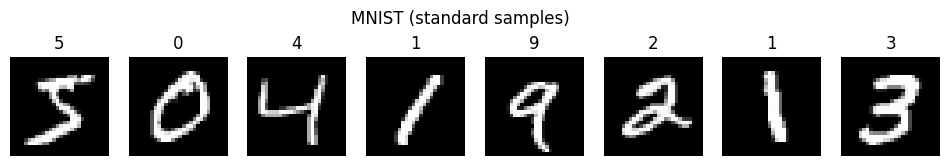

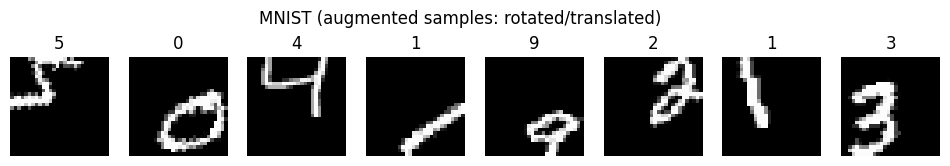

In [18]:
def show_samples(dataset, title, n=8):
    plt.figure(figsize=(12, 2))
    for i in range(n):
        img, label = dataset[i]
        plt.subplot(1, n, i+1)
        plt.imshow(img.squeeze(0), cmap="gray")
        plt.title(str(label))
        plt.axis("off")
    plt.suptitle(title)
    plt.show()

show_samples(train_noaug, "MNIST (standard samples)")
show_samples(train_aug, "MNIST (augmented samples: rotated/translated)")


## 3) DataLoaders

We'll use mini-batches. If you run out of memory, reduce `batch_size`.


In [19]:
batch_size = 128

train_loader_noaug = DataLoader(train_noaug, batch_size=batch_size, shuffle=True)
train_loader_aug   = DataLoader(train_aug, batch_size=batch_size, shuffle=True)

test_loader_std    = DataLoader(test_std, batch_size=batch_size, shuffle=False)
test_loader_trans  = DataLoader(test_trans, batch_size=batch_size, shuffle=False)

## 4) CNN model

A simple CNN for MNIST:

- Conv(1→16) + ReLU + MaxPool
- Conv(16→32) + ReLU + MaxPool
- Flatten
- FC(32×7×7 → 128) + ReLU
- FC(128 → 10)

This is intentionally small so it trains quickly on Colab.


In [21]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 28x28 -> 14x14

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)   # 14x14 -> 7x7
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = SimpleCNN().to(device)
model


SimpleCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1568, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)

## 5) Training & evaluation utilities

We use:
- Loss: `CrossEntropyLoss` (10 classes)
- Optimizer: `Adam`

We'll train the same architecture twice:
1) on standard MNIST (no aug)
2) on augmented MNIST (rotation + translation)


In [23]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


def train_one_epoch(model, loader, optimizer):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    return total_loss / len(loader), correct / total

def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0
    total_loss = 0.0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        with torch.no_grad():
            outputs = model(images)
            loss = criterion(outputs, labels)

        total_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    return total_loss / len(loader), correct / total


## 6) Train baseline CNN (no augmentation)

You can increase `epochs` if you wants


In [27]:
def train_model(train_loader, epochs=3, lr=1e-3):
    model = SimpleCNN().to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer)
        va_loss, va_acc = evaluate(model, test_loader_std)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        print(f"Epoch {epoch}/{epochs} | train_loss={tr_loss:.4f} train_acc={tr_acc:.3f} | test_std_acc={va_acc:.3f}")
    return model, history

epochs = 5
cnn_noaug, hist_noaug = train_model(train_loader_noaug, epochs=epochs)

Epoch 1/5 | train_loss=0.2744 train_acc=0.919 | test_std_acc=0.974
Epoch 2/5 | train_loss=0.0748 train_acc=0.977 | test_std_acc=0.982
Epoch 3/5 | train_loss=0.0518 train_acc=0.984 | test_std_acc=0.987
Epoch 4/5 | train_loss=0.0398 train_acc=0.988 | test_std_acc=0.986
Epoch 5/5 | train_loss=0.0337 train_acc=0.989 | test_std_acc=0.988


## 7) Train CNN with augmentation (rotation + translation)

Augmentation often makes training harder (samples are more varied), but increases robustness.


In [28]:
cnn_aug, hist_aug = train_model(train_loader_aug, epochs=epochs)

Epoch 1/5 | train_loss=1.2856 train_acc=0.565 | test_std_acc=0.904
Epoch 2/5 | train_loss=0.5668 train_acc=0.826 | test_std_acc=0.916
Epoch 3/5 | train_loss=0.4291 train_acc=0.867 | test_std_acc=0.940
Epoch 4/5 | train_loss=0.3612 train_acc=0.888 | test_std_acc=0.938
Epoch 5/5 | train_loss=0.3177 train_acc=0.901 | test_std_acc=0.947


## 8) Evaluate robustness

We evaluate both models on:
- Standard MNIST test set
- Transformed MNIST test set (rotated/translated)

A robust model should lose **less accuracy** on the transformed test set.


In [29]:
noaug_std_loss, noaug_std_acc = evaluate(cnn_noaug, test_loader_std)
noaug_tr_loss,  noaug_tr_acc  = evaluate(cnn_noaug, test_loader_trans)
aug_std_loss,   aug_std_acc   = evaluate(cnn_aug, test_loader_std)
aug_tr_loss,    aug_tr_acc    = evaluate(cnn_aug, test_loader_trans)
print("=== Baseline CNN (no augmentation) ===")
print(f"Test (standard):    acc={noaug_std_acc:.3f}")
print(f"Test (transformed): acc={noaug_tr_acc:.3f}")
print()
print("=== CNN trained with augmentation ===")
print(f"Test (standard):    acc={aug_std_acc:.3f}")
print(f"Test (transformed): acc={aug_tr_acc:.3f}")


=== Baseline CNN (no augmentation) ===
Test (standard):    acc=0.988
Test (transformed): acc=0.252

=== CNN trained with augmentation ===
Test (standard):    acc=0.947
Test (transformed): acc=0.911


### Plot training curves (optional)

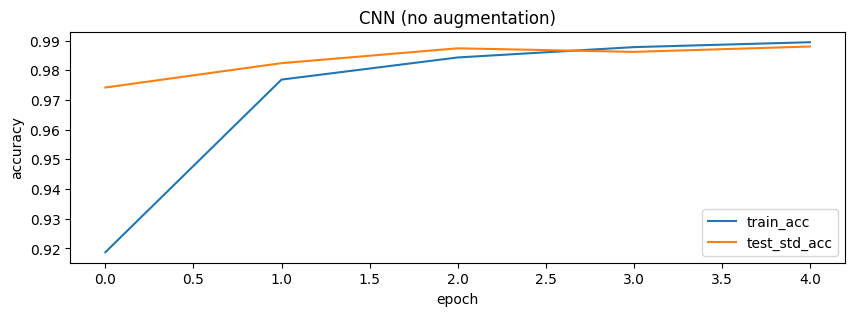

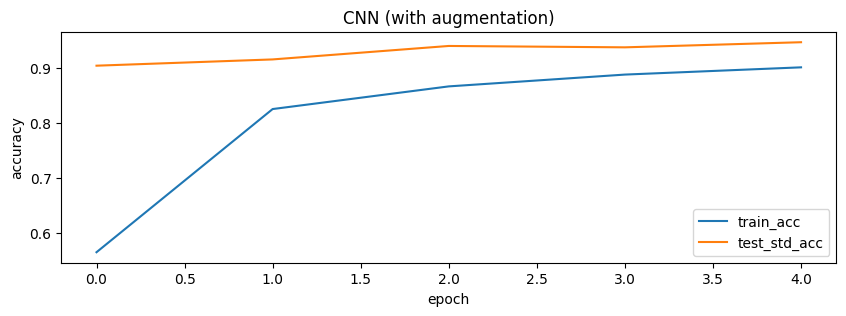

In [30]:
def plot_hist(hist, title):
    plt.figure(figsize=(10, 3))
    plt.plot(hist["train_acc"], label="train_acc")
    plt.plot(hist["val_acc"], label="test_std_acc")
    plt.title(title)
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.legend()
    plt.show()

plot_hist(hist_noaug, "CNN (no augmentation)")
plot_hist(hist_aug, "CNN (with augmentation)")


## 9) Visualizing CNN layers

We will look at:
1. **First-layer convolution filters** (weights of Conv1)
2. **Feature maps (activations)** for a single image

This helps you *see* what the CNN learns.


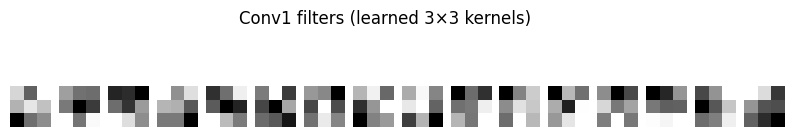

In [31]:
def show_conv1_filters(model, max_filters=16):
    conv1 = None
    for layer in model.features:
        if isinstance(layer, nn.Conv2d):
            conv1 = layer
            break
    W = conv1.weight.detach().cpu()  # (out_channels, in_channels, kH, kW)

    n = min(W.shape[0], max_filters)
    plt.figure(figsize=(10, 2))
    for i in range(n):
        plt.subplot(1, n, i+1)
        plt.imshow(W[i, 0], cmap="gray")
        plt.axis("off")
    plt.suptitle("Conv1 filters (learned 3×3 kernels)")
    plt.show()

show_conv1_filters(cnn_aug)


### Feature maps (activations)

We take **one test image**, pass it through the CNN, and visualize outputs after each convolution layer.


In [32]:
@torch.no_grad()
def get_activations(model, x):
    activations = []
    cur = x
    for layer in model.features:
        cur = layer(cur)
        if isinstance(layer, nn.Conv2d):
            activations.append(cur.detach().cpu())
    return activations

# One sample from the standard test set
img, label = test_std[0]
x = img.unsqueeze(0).to(device)

acts = get_activations(cnn_aug, x)

print("Label:", label)
print("Activation shapes:", [a.shape for a in acts])


Label: 7
Activation shapes: [torch.Size([1, 16, 28, 28]), torch.Size([1, 32, 14, 14])]


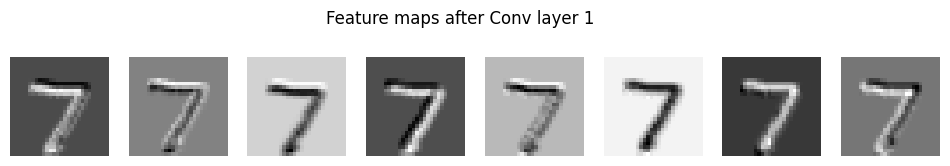

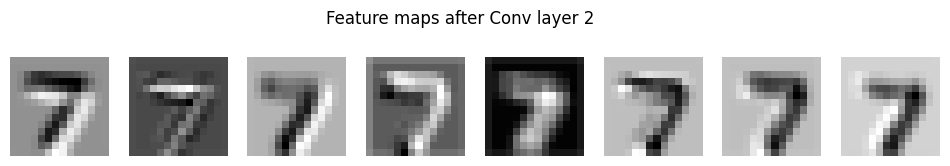

In [33]:
def show_feature_maps(activation, title, max_maps=8):
    C = activation.shape[1]
    n = min(C, max_maps)
    plt.figure(figsize=(12, 2))
    for i in range(n):
        plt.subplot(1, n, i+1)
        plt.imshow(activation[0, i], cmap="gray")
        plt.axis("off")
    plt.suptitle(title)
    plt.show()

for idx, act in enumerate(acts, start=1):
    show_feature_maps(act, f"Feature maps after Conv layer {idx}", max_maps=8)


## 10) Final reflection 

1. Compare **standard test accuracy** vs **transformed test accuracy** for both models. What do you notice?

The baseline model excels on the standard test with 98.8% accuracy but collapses to 25.2% on the transformed test. The augmented model drops slightly to 94.7% on the standard test but maintains a high performance of 91.1% on the transformed one.

2. Why does augmentation help on the transformed test set?

Augmentation exposes the network to geometric variations during training, forcing it to learn invariant features. The model thus recognizes the intrinsic shape of the digit regardless of its position or orientation.

3. Do we always expect augmentation to improve standard test accuracy? Why/why not?

No, augmentation does not always improve standard accuracy, which drops here from 98.8% to 94.7%. By making the task more complex with varied data, the model may struggle to over-specialize on standard images if its capacity is limited.

**Conclusion:** In the next LAB(2), we will go deeper into CNN architectures, and you should see further accuracy improvements.
